In [1]:
import pandas as pd

file_path = 'df_bal.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,6763755,1998.0,2.0,35,43907,0,1.0,1.0,1.0,1.0,...,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0,0,2
1,3515966,66.0,2.0,29,8408,0,3.0,1.0,1.0,1.0,...,0.0,0.666667,0.0,0.333333,0.0,0.0,0.0,0,0,0
2,9250631,638.0,2.0,52,5513,0,3.0,1.0,1.0,1.0,...,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0,0,1
3,4719309,295.0,2.0,32,5002,0,3.0,1.0,1.0,1.0,...,0.0,0.000000,0.5,0.500000,0.0,0.0,0.0,0,0,1
4,5385510,209.0,2.0,33,2502,0,2.0,1.0,1.0,1.0,...,0.0,0.000000,0.5,0.000000,0.0,0.0,0.0,0,0,0


In [2]:
df = df.drop(columns=['VL_RENDA_MEDIA_FAM'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 49 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  float64
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   IN_FORMULARIO_SUP2_FAM        999999 non-null  int64  
 5   QT_PESSOAS_DOMIC_FAM          999999 non-null  float64
 6   QT_FAMILIAS_DOMIC_FAM         999999 non-null  float64
 7   CO_ESPECIE_DOMIC_FAM          999999 non-null  float64
 8   CO_LOCAL_DOMIC_FAM            999999 non-null  float64
 9   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 10  QT_COMODOS_DORMITORIO_FAM     999999 non-null  float64
 11  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 12  CO_MATERIAL_PISO_FAM          999999 non-nul

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 999999 entries, 0 to 999998
Series name: classe_renda
Non-Null Count   Dtype
--------------   -----
999999 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [6]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'PBF',
       'DIAS_ATUALIZACAO', 'DIAS_CADASTRO', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRA

## Análise de correlação das variáveis

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    'PBF',
]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

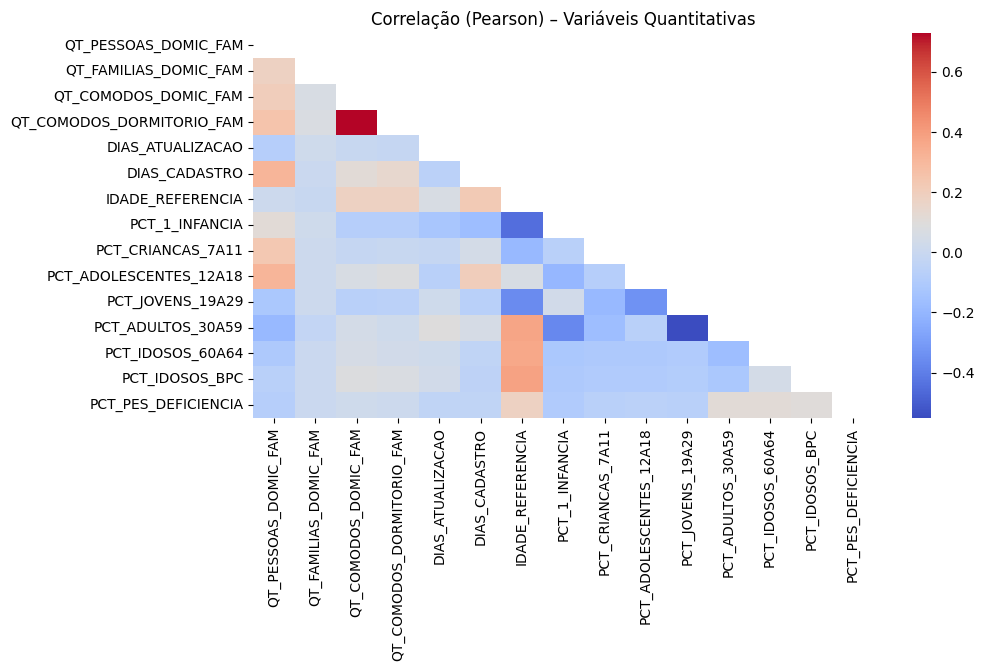

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = df[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [9]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
27,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.734603
95,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.554600
69,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.454762
75,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.376080
80,PCT_1_INFANCIA,PCT_ADULTOS_30A59,-0.374503
73,IDADE_REFERENCIA,PCT_ADULTOS_30A59,0.373122
72,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.364760
74,IDADE_REFERENCIA,PCT_IDOSOS_60A64,0.361708
90,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,-0.338412
4,QT_PESSOAS_DOMIC_FAM,DIAS_CADASTRO,0.311480


In [10]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


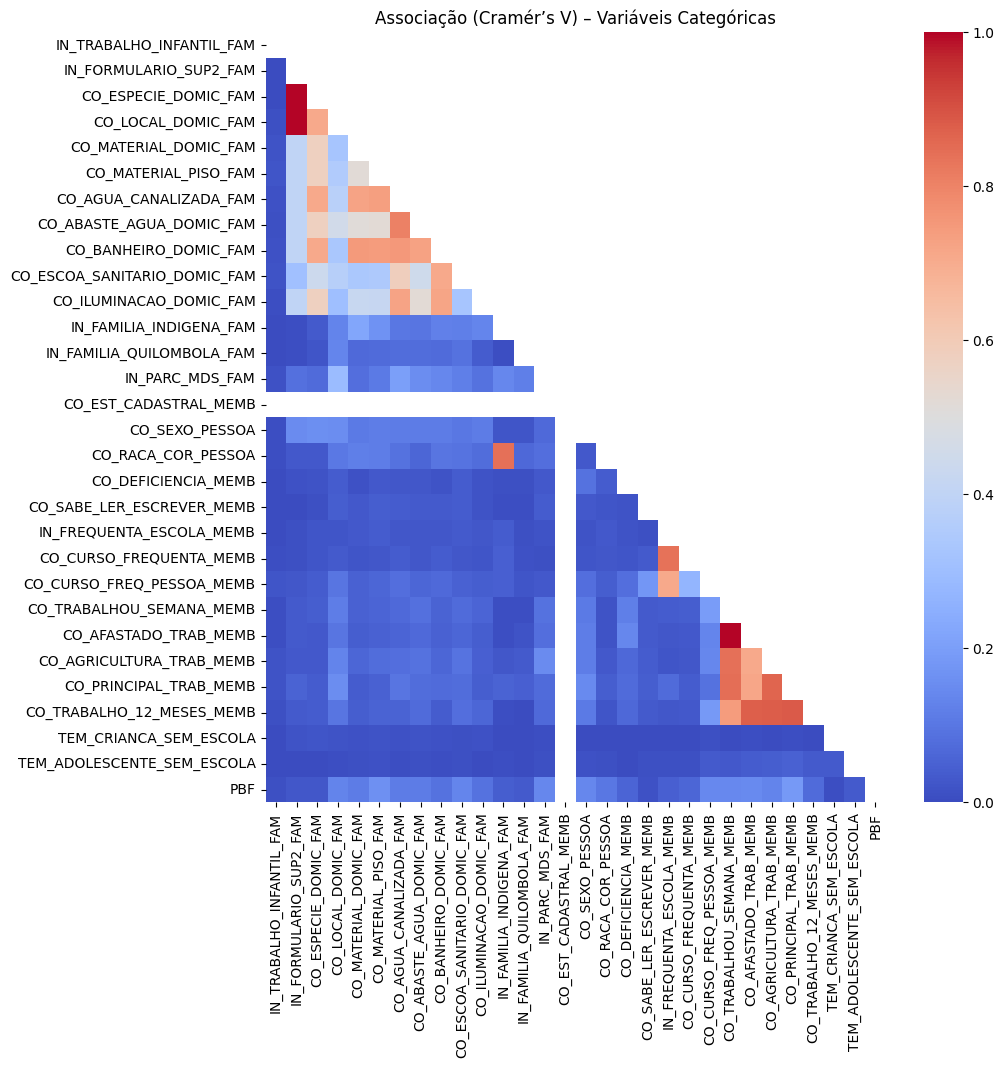

In [11]:
# Selecionar todas as categóricas
df_cat = df[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [12]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
378  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
28     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   1.000000
29     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   1.000000
396    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.886037
392  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.879521
387     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.877785
391  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.864705
380  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.845238
256   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.841189
379  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.840944


In [13]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
378  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
28     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   1.000000
29     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   1.000000
396    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.886037
392  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.879521
387     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.877785
391  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.864705
380  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.845238
256   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.841189
379  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.840944
351  IN_FREQUENTA_ESCOLA_MEMB    CO_CURSO_FREQUENTA_MEMB   0.838597
153    CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.806694


In [14]:
df = df.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_AGUA_CANALIZADA_FAM'])

In [15]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'PBF', 'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
       'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'IDADE_REFERENCIA',
       'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64', 'PCT_I

In [16]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,6763755,2.0,35,43907,1.0,1.0,1.0,1.0,4,1.0,...,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0,0,2
1,3515966,2.0,29,8408,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.666667,0.0,0.333333,0.0,0.0,0.0,0,0,0
2,9250631,2.0,52,5513,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0,0,1
3,4719309,2.0,32,5002,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.500000,0.0,0.0,0.0,0,0,1
4,5385510,2.0,33,2502,2.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.000000,0.0,0.0,0.0,0,0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  float64
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          999999 non-null  float64
 5   QT_FAMILIAS_DOMIC_FAM         999999 non-null  float64
 6   CO_ESPECIE_DOMIC_FAM          999999 non-null  float64
 7   CO_LOCAL_DOMIC_FAM            999999 non-null  float64
 8   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     999999 non-null  float64
 10  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          999999 non-null  int64  
 12  CO_ABASTE_AGUA_DOMIC_FAM      999999 non-nul

In [18]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,6763755,2.0,35,43907,1.0,1.0,1.0,1.0,4,1.0,...,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0,0,2
1,3515966,2.0,29,8408,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.666667,0.0,0.333333,0.0,0.0,0.0,0,0,0
2,9250631,2.0,52,5513,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0,0,1
3,4719309,2.0,32,5002,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.500000,0.0,0.0,0.0,0,0,1
4,5385510,2.0,33,2502,2.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.000000,0.0,0.0,0.0,0,0,0


## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [19]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
        'IN_TRABALHO_INFANTIL_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
        'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
        'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
        'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
        'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
        'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
        'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        'PBF',
    ]

pct_cols = [
        'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
        'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
        'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
        'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
        'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']

target_col = "classe_renda"
id_col = "ID_FAM_ANON"


In [20]:
# X e y brutos
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB', 'CO_TRABALHO_12_MESES_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB']


In [21]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [22]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [23]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [24]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [25]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [26]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [27]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [29]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM',
                                  'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADO...
                                  'CO_MATERIAL_DOMIC_FAM',
                                  'CO_MATERIAL_PISO_FAM',
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [30]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__DIAS_ATUALIZACAO,quant__DIAS_CADASTRO,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,...,multicat__CO_PRINCIPAL_TRAB_MEMB_4.0,multicat__CO_PRINCIPAL_TRAB_MEMB_5.0,multicat__CO_PRINCIPAL_TRAB_MEMB_6.0,multicat__CO_PRINCIPAL_TRAB_MEMB_7.0,multicat__CO_PRINCIPAL_TRAB_MEMB_8.0,multicat__CO_PRINCIPAL_TRAB_MEMB_9.0,multicat__CO_PRINCIPAL_TRAB_MEMB_10.0,multicat__CO_PRINCIPAL_TRAB_MEMB_11.0,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.05,0.02,0.052083,0.037037,0.276639,0.601590,0.35,0.25,0.0,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,21500.0
1,0.02,0.02,0.052083,0.024691,0.952186,0.244939,0.24,0.00,0.0,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,50308.0
2,0.03,0.02,0.062500,0.037037,0.403689,0.062639,0.54,0.00,0.0,0.50,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,43.0,7609.0
3,0.02,0.02,0.062500,0.037037,0.147541,0.302915,0.83,0.00,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,9600.0
4,0.03,0.02,0.041667,0.024691,0.396175,0.061473,0.43,0.00,0.0,0.50,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,51009.0


## Pipeline completo (preprocessamento + modelo)

In [31]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'DIAS_ATUALIZACAO',
                                                   'DIAS_CADASTRO',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA...
                                                   'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                                   'CO_ILUMINACAO_DOMIC_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

## Avaliação completa do modelo

### Predições do teste

In [32]:
y_pred = pipeline_rf.predict(X_test)
y_proba = pipeline_rf.predict_proba(X_test)  # para AUC

### Acurácia e F1

In [33]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Acurácia: {acc:.3f}")
print(f"F1 macro: {f1_macro:.3f}")
print(f"F1 weighted: {f1_weighted:.3f}")

Acurácia: 0.674
F1 macro: 0.661
F1 weighted: 0.661


### AUC

In [34]:
# Se classe_renda for multiclasse, usamos one-vs-rest
auc_ovr = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"AUC (OVR, weighted): {auc_ovr:.3f}")

AUC (OVR, weighted): 0.845


### Classification report

In [35]:
print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.75      0.72     66666
           1       0.57      0.42      0.48     66667
           2       0.72      0.85      0.78     66667

    accuracy                           0.67    200000
   macro avg       0.66      0.67      0.66    200000
weighted avg       0.66      0.67      0.66    200000



### Matriz de confusão

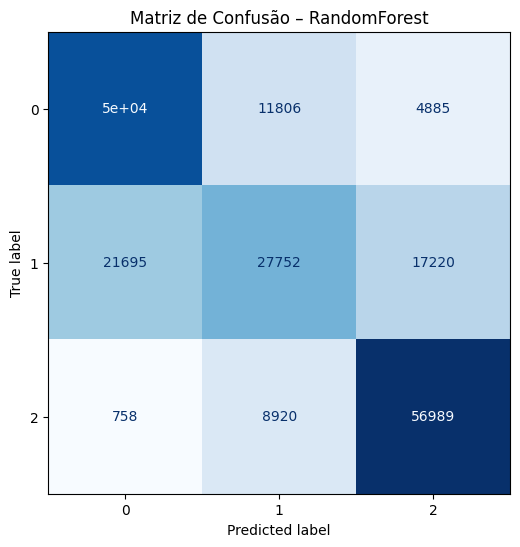

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão – RandomForest")
plt.show()

### Comparando diversos modelos

In [37]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from xgboost import XGBClassifier
from sklearn.base import clone

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, multi_class="auto", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",  # multi-classe com predict_proba
        eval_metric="mlogloss",
        tree_method="hist",          # mais rápido em bases grandes
        random_state=42,
        n_jobs=-1
    ),
}

results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    # métricas principais
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")
    
    # AUC (se o modelo tiver predict_proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan
    
    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "auc_weighted_ovr": auc
    })

df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
df_results



Treinando modelo: RandomForest

Treinando modelo: LogisticRegression


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Treinando modelo: GradientBoosting

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost


,modelo,accuracy,f1_weighted,f1_macro,auc_weighted_ovr
4,XGBoost,0.683890,0.670744,0.670744,0.855898
3,HistGradientBoosting,0.682850,0.669263,0.669263,0.854748
0,RandomForest,0.673580,0.660855,0.660855,0.844995
2,GradientBoosting,0.670930,0.650938,0.650939,0.842047
1,LogisticRegression,0.636345,0.584618,0.584619,0.801858
